Research Question 3: How does the time between winning possession in your own half and the first shot correlate with the probability of scoring (based on xGoals)?

Retrieving the Data:

In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

import soccerdata as sd


data = sd.WhoScored(leagues="GER-Bundesliga", seasons="2024/2025", headless=True)

# Creating a list of all the game IDs of the Bundesliga season 2024/2025
game_ids = data.read_schedule()["game_id"].to_list()

events = data.read_events(match_id=game_ids)

# Defining possession IDs for each possession
events["poss_change"] = events["team_id"] != events["team_id"].shift()
events["possession_id"] = events["poss_change"].cumsum()

shot_types = ["Goal", "MissedShots", "SavedShot", "ShotOnPost"]
events["is_shot"] = events["type"].isin(shot_types)

possessions_with_shot = events.groupby("possession_id")["is_shot"].transform("any")

shot_results = events[events["is_shot"]].groupby("possession_id")["is_goal"].any()

possession_win = ["Tackle", "Interception", "BallRecovery"]

# Determining the time difference between possession gain and shot
events["poss_gain_time"] = (events["minute"] * 60) + events["second"]
first_shot_time = events[events["is_shot"]].groupby("possession_id")["poss_gain_time"].min()

# Filter for all events that were a possession gain in the own half, which resulted in a shot
own_half_wins_with_shot = events[
    (events["type"].isin(possession_win)) & 
    (events["outcome_type"] == "Successful") & 
    (events["x"] < 50) &
    (possessions_with_shot)
].copy()

# Merge the first_shot_time table
own_half_wins_with_shot["shot_time"] = own_half_wins_with_shot["possession_id"].map(first_shot_time)

own_half_wins_with_shot["time_delta"] = own_half_wins_with_shot["shot_time"] - own_half_wins_with_shot["poss_gain_time"]

# Merge the shot_result table
own_half_wins_with_shot["is_goal"] = own_half_wins_with_shot["possession_id"].map(shot_results)

# Make a dataframe with only the relevant data
df_RQ3 = own_half_wins_with_shot[["is_goal","time_delta"]].copy()

df_RQ3 = df_RQ3[df_RQ3["time_delta"] >= 5].copy()

df_RQ3 = df_RQ3.sort_values(by="time_delta")

df_RQ3.to_json("RQ3.json", orient="records", indent=4)
df_RQ3.to_csv("RQ3.csv", index=False)


[03/12/26 10:10:01] INFO     No custom team name replacements found. You can configure these in       ]8;id=140889;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=257170;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py#92\92]8;;\
                             C:\Users\hinri\soccerdata\config\teamname_replacements.json.                          

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=505220;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=684161;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py#198\198]8;;\
                             C:\Users\hinri\soccerdata\config\league_dict.json.                                    

                    INFO     Saving cached data to C:\Users\hinri\soccerdata\data\WhoScored          ]8;id=156830;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=237443;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_common.py#249\249]8;;\

[03/12/26 10:10:09] INFO     Retrieving calendar for GER-Bundesliga 2425                           ]8;id=531604;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=560305;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#365\365]8;;\

                    INFO     [1/10] Retrieving fixtures for GER-Bundesliga 2425                    ]8;id=386829;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=790748;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#396\396]8;;\

...

                    INFO     [302/306] Retrieving game with id=1834455                             ]8;id=534611;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=470558;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [303/306] Retrieving game with id=1834451                             ]8;id=648561;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=316118;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [304/306] Retrieving game with id=1834459                             ]8;id=686587;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=825934;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [305/306] Retrieving game with id=1834447                             ]8;id=859335;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=467256;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [306/306] Retrieving game with id=1834463                             ]8;id=674298;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=623600;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

Creating the Visualization:

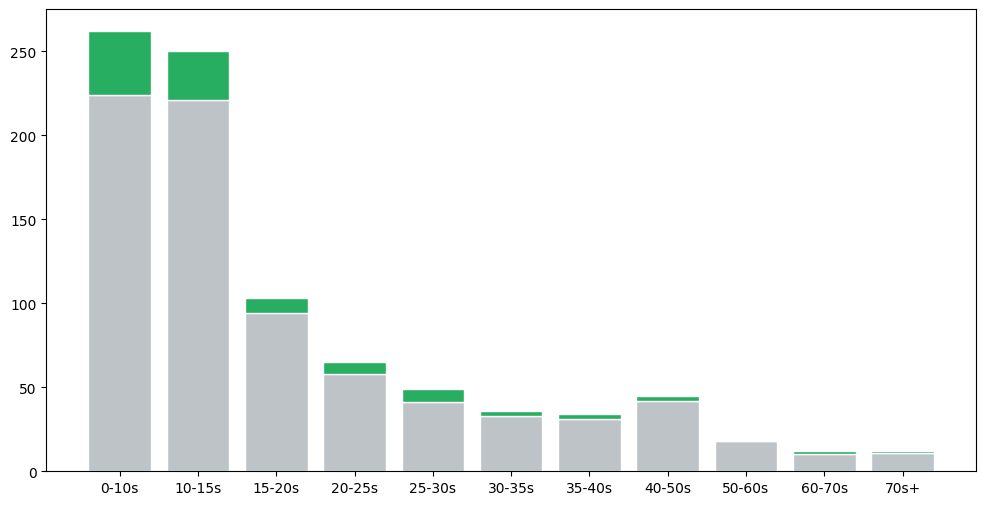

In [14]:
# Defining intervalls
bins = [0, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, float('inf')]
labels = ['0-10s', '10-15s', '15-20s', '20-25s', '25-30s', '30-35s', '35-40s', '40-50s', '50-60s', '60-70s', '70s+']

# Assigning intervalls to each element of the dataframe
df_RQ3["intervalls"] = pd.cut(
    df_RQ3["time_delta"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

goals = []
no_goals = []

for label in labels:
    subset = df_RQ3[df_RQ3["intervalls"] == label]

    g = int(subset[subset["is_goal"]==True].shape[0])
    ng = int(subset[subset["is_goal"] == False].shape[0])

    goals.append(g)
    no_goals.append(ng)

plt.figure(figsize=(12, 6))

plt.bar(labels, no_goals, color='#bdc3c7', label='No Goal', edgecolor='white')
plt.bar(labels, goals, bottom=no_goals, color='#27ae60', label='Goal', edgecolor='white')

plt.savefig("Goals.png")

plt.show()